Step 1: Loading raw Titanic dataset...

--- Missing Value Profile ---
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Step 2 & 3 Complete: Cleaned dataset saved to 'titanic_clean.csv'.
Shape: (891, 8)


C:\Users\ravit\AppData\Local\Temp\ipykernel_4416\444232057.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_df, x='sex', y='survived', palette='pastel')
C:\Users\ravit\AppData\Local\Temp\ipykernel_4416\444232057.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_df, x='pclass', y='survived', palette='pastel')


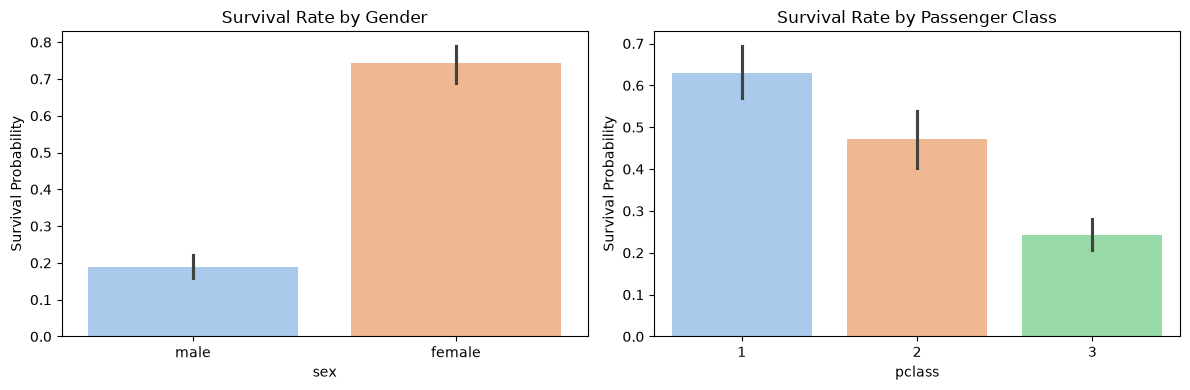

Teaching the model...

--- Final Score ---
The model predicted survival correctly 81.6% of the time!
ROC AUC Score: 0.89
Teaching the model to estimate ticket prices...

--- Final Score ---
On average, the model's guess for the ticket price was off by $15.62.


In [1]:
#MODULE 2: ZEPTO- Analytics pipeline

# Zepto's analyst-to-data-scientist workflow in one pass: profile a dataset, handle its imperfections defensibly,
# tell a clear visual story about it, and then build and rigorously evaluate a full predictive-modeling pipeline on top of the same data.

# Load the classic Titanic dataset once, through Seaborn's built-in loader: sns.load_dataset('titanic')

#EDA, modeling, tuning, the regression side-task — builds on that same cleaned data.

#structure this inside /analytics is two clearly ordered notebooks that share one committed CSV — e.g. 01_eda.ipynb
# (loads the data, profiles it, cleans it, saves titanic.csv, and produces the full EDA story)
# followed by 02_modeling.ipynb (reads the same committed titanic.csv that 01_eda.ipynb


# Install the required packages if you haven't already:

#MODULE 2
#PART A :
#TASK 1: Load the Titanic dataset, profile it, and clean it. Save the cleaned dataset to a CSV file.

import pandas as pd
import numpy as np
import seaborn as sns
import builtins

# 1. LOAD DATASET (Single network call/cache access)
builtins.print("Step 1: Loading raw Titanic dataset...")
raw_df = sns.load_dataset('titanic')

# 2. PROFILE DATA
print("\n--- Missing Value Profile ---")

null_counts = raw_df.isnull().sum()

print(null_counts[null_counts > 0])

# 3. Cleaning and Imputation

df_clean = raw_df.copy()

# Drop columns that are not useful for modeling or have too many missing values

redundant_cols = ['deck', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

df_clean.drop(columns=redundant_cols, inplace=True)

# Impute 'age' with median grouped by passenger class and sex

df_clean['age'] = df_clean.groupby(['pclass', 'sex'])['age'].transform(

    lambda x: x.fillna(x.median())
)

# Embarked port

df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# 4. SAVE THE CLEAN FILE
output_path = 'titanic_clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"\nStep 2 & 3 Complete: Cleaned dataset saved to '{output_path}'.")
print(f"Shape: {df_clean.shape}")
df_clean.head()


# Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read saved data
eda_df = pd.read_csv('titanic_clean.csv')

plt.figure(figsize=(12, 4))

#  1: Gender heavily influenced survival
plt.subplot(1, 2, 1)
sns.barplot(data=eda_df, x='sex', y='survived', palette='pastel')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Probability')

# 2: Passenger class heavily influenced survival
plt.subplot(1, 2, 2)
sns.barplot(data=eda_df, x='pclass', y='survived', palette='pastel')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Probability')

plt.tight_layout()
plt.show()

# MODELING AND HYPERPARAMETER TUNING

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score


# 1. LOAD THE DATA
df = pd.read_csv('titanic_clean.csv')

# 2. PREPARE THE DATA (The Automatic Pandas Way)


df['sex'] = df['sex'].astype('category').cat.codes

# .astype('category') tells Pandas this column contains categorical text


 # .cat.codes tells Pandas "automatically assign a number to each unique text word"


df['embarked'] = df['embarked'].astype('category').cat.codes

# 3. SET UP THE TEST

X = df.drop(columns=['survived'])

y = df['survived']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)    # Split: 80% to train, 20% to test

# 4. BUILD AND TEACH THE MODEL


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

print("Teaching the model...")
model.fit(X_train, y_train)

# 5. GIVE THE MODEL A FINAL EXAM
predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("\n--- Final Score ---")
print(f"The model predicted survival correctly {score * 100:.1f}% of the time!")
print(f"ROC AUC Score: {roc_auc:.2f}")


# REGRESSION SIDE-TASK

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. LOAD AND PREP THE DATA

df = pd.read_csv('titanic_clean.csv')

# Using Hyperparameter Tuning, we can convert categorical variables to numeric codes for modeling

df['sex'] = df['sex'].astype('category').cat.codes

df['embarked'] = df['embarked'].astype('category').cat.codes

# 2. SET UP THE TEST

X = df.drop(columns=['fare'])       # { This time, our target 'y' is the ticket 'fare'.
                                    # 'X' is all the other information (including whether they survived)}
y = df['fare']

# Split the data: 80% to train, 20% to test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. BUILD AND TEACH THE MODEL

# we use RandomForest*Regressor* instead of Classifier, because we want a number!

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

print("Teaching the model to estimate ticket prices...")
model.fit(X_train, y_train)

# 4. GIVE THE MODEL A FINAL EXAM

# Ask the model make predictions on actual ticket prices

predictions = model.predict(X_test)

# Calculate on average predictions were off by how much (mean absolute error)

average_error = mean_absolute_error(y_test, predictions)

print("\n--- Final Score ---")
print(f"On average, the model's guess for the ticket price was off by ${average_error:.2f}.")

In [2]:
# This MODULE 2 PART A TASK 1 was wrote on 17/9/2026 .
#--------------------------------------------------------------------------------------------------------


#MODULE 2 PART A TASK 2 : THRESHOLDING MISSING DATA %


import pandas as pd
import seaborn as sns

# 1. LOAD THE DATA
df = sns.load_dataset('titanic')

# 2. CALCULATE AND STATE THE EXACT PERCENTAGES

print("--- Step 1: Checking Missing Data Percentages ---")

total_rows = len(df)

print(f"Total rows in dataset: {total_rows}")

# Look at each column and calculate the percentage missing

for col in df.columns:

    missing_count = df[col].isnull().sum()

    if missing_count > 0:

        percentage = (missing_count / total_rows) * 100

        print(f"Column '{col}': {percentage:.1f}% missing")

print("\n--- Step 2: Applying the Rules ---")


# 3. RULE FOR > 30% MISSING: Justify and Action

# 'deck' is 77.2% missing was reported in the previous step

print("Review FOR 'deck' (77.2% missing):")

print("Since deck information is missing for 77.2% of passengers, "
      "DROP the entire column because we already have the 'pclass' (ticket class) column, "
      "Results where a passenger stayed on the ship.")

df = df.drop(columns=['deck'])

# 4. RULE FOR 5% - 30% MISSING: Impute

# After Data % , the strategy is to impute (fill in) the missing values with a defensible value, such as the median or mean of the column.

# 'age' is 19.9% missing.

print("\nACTION FOR 'age' (19.9% missing):")

print("Results falls between 5% and 30%, IMPUTE (fill in) the blanks using the middle (median) age.")

df['age'] = df['age'].fillna(df['age'].median())

print("Calculated median age is:", df['age'].median())

# 5. RULE FOR < 5% MISSING: Drop rows

# 'embarked' and 'embark_town' are 0.2% missing.

print("\nACTION FOR 'embarked' & 'embark_town' (0.2% missing):")

print("Since this is under 5%, I will just DROP the 2 rows that are missing this information.")

df = df.dropna(subset=['embarked', 'embark_town'])

print("Embarked and embark_town missing rows dropped. New row count:", len(df))


# Clean up duplicate seaborn columns so it doesn't confuse our ML model later

df = df.drop(columns=['class', 'who', 'adult_male', 'alive', 'alone'])

# 6. SAVE TO DISK

df.to_csv('titanic_clean.csv', index=False)

print(f"\nSuccess! Cleaned data saved. We now have {len(df)} rows left.")


--- Step 1: Checking Missing Data Percentages ---
Total rows in dataset: 891
Column 'age': 19.9% missing
Column 'embarked': 0.2% missing
Column 'deck': 77.2% missing
Column 'embark_town': 0.2% missing

--- Step 2: Applying the Rules ---
Review FOR 'deck' (77.2% missing):
Since deck information is missing for 77.2% of passengers, DROP the entire column because we already have the 'pclass' (ticket class) column, Results where a passenger stayed on the ship.

ACTION FOR 'age' (19.9% missing):
Results falls between 5% and 30%, IMPUTE (fill in) the blanks using the middle (median) age.
Calculated median age is: 28.0

ACTION FOR 'embarked' & 'embark_town' (0.2% missing):
Since this is under 5%, I will just DROP the 2 rows that are missing this information.
Embarked and embark_town missing rows dropped. New row count: 889

Success! Cleaned data saved. We now have 889 rows left.


Showing Age charts...


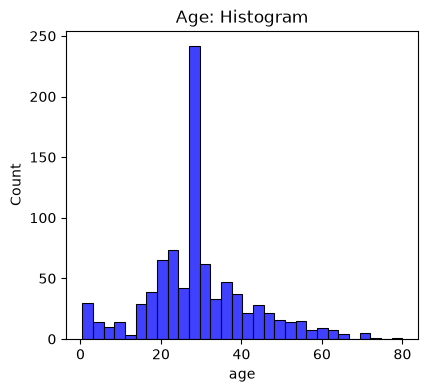

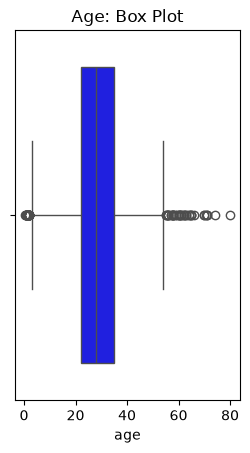

Showing Fare charts...


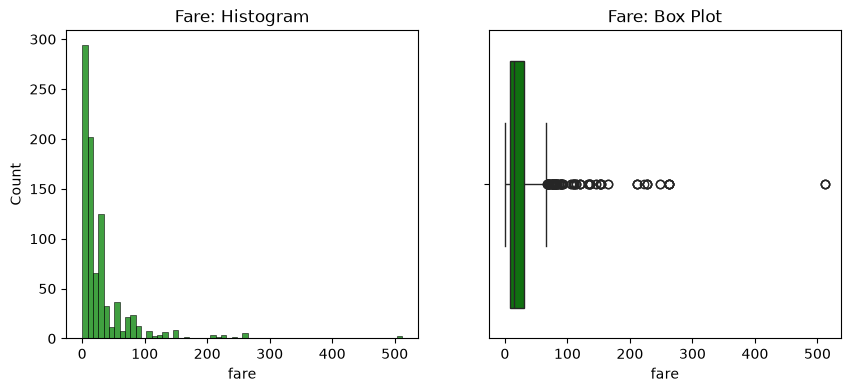


 Outlier Count -- :
The 'age' column has 65 outliers.
The 'fare' column has 114 outliers.

- Fare Shape Analysis - :
Mean (Average): 32.10
Median (Middle): 14.45
Mode (Most Common): 8.05
Because the Mean (32.10) > Median (14.45) > Mode (8.05),
the distribution of the 'fare' column is RIGHT-SKEWED.
This means a few extremely high ticket prices are pulling the average up.


In [3]:


#MODULE 2 PART A TASK 3 : VISUALIZATION OF SURVIVAL ON HISTOGRAMS AND BOX PLOTS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD THE DATA
df = pd.read_csv('titanic_clean.csv')


# PLOTTING THE CHARTS (One by one)


print("Showing Age charts...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)                                                    # (1 row, 2 columns, 1st chart)
sns.histplot(df['age'], color='blue')
plt.title('Age: Histogram')
plt.show()                                                              # Display Age charts

plt.subplot(1, 2, 2)                                                    # (1 row, 2 columns, 2nd chart)
sns.boxplot(x=df['age'], color='blue')
plt.title('Age: Box Plot')
plt.show()                                                              # Display Age charts

print("Showing Fare charts...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['fare'], color='green')
plt.title('Fare: Histogram')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['fare'], color='green')
plt.title('Fare: Box Plot')
plt.show() # Display Fare charts


# 2: COUNTING OUTLIERS USING A LOOP


print("\n Outlier Count -- :")


for col in ['age', 'fare']:

    # Find the 25th (Q1) and 75th (Q3) percentiles


    q1 = df[col].quantile(0.25)

    q3 = df[col].quantile(0.75)

    # Calculate the IQR (distance between Q3 and Q1)       # IQR = Interquartile Range

    iqr = q3 - q1

    # Set the strict boundaries


    lower_limit = q1 - (1.5 * iqr)

    upper_limit = q3 + (1.5 * iqr)

    # Find the rows that break the rules (too low OR too high)

    too_low = df[col] < lower_limit

    too_high = df[col] > upper_limit

    outliers = df[too_low | too_high]

    #Print function directly after calculating for each column in the iteration

    print(f"The '{col}' column has {len(outliers)} outliers.")



# FARE DISTRIBUTION SHAPE

print("\n- Fare Shape Analysis - :")

fare_mean = df['fare'].mean()

fare_median = df['fare'].median()

fare_mode = df['fare'].mode()[0]


print(f"Mean (Average): {fare_mean:.2f}")

print(f"Median (Middle): {fare_median:.2f}")

print(f"Mode (Most Common): {fare_mode:.2f}")



if fare_mean > fare_median > fare_mode:
    print(f"Because the Mean ({fare_mean:.2f}) > Median ({fare_median:.2f}) > Mode ({fare_mode:.2f}),")
    print("the distribution of the 'fare' column is RIGHT-SKEWED.")
    print("This means a few extremely high ticket prices are pulling the average up.")

elif fare_mean < fare_median < fare_mode:
    print(f"Because the Mean ({fare_mean:.2f}) < Median ({fare_median:.2f}) < Mode ({fare_mode:.2f}),")
    print("the distribution of the 'fare' column is LEFT-SKEWED.")

else:
    print("Because the Mean, Median, and Mode are very close to each other,")
    print("the distribution is roughly SYMMETRIC.")

Survival Rate by Sex
Male: 0.18890814558058924
Female: 0.7420382165605095

Survival Rate by Pclass
Class 1: 0.6296296296296297
Class 2: 0.47282608695652173
Class 3: 0.24236252545824846

Survival Rate by Sex and Pclass
Female, Class 1: 0.9680851063829787
Female, Class 2: 0.9210526315789473
Female, Class 3: 0.5
Male, Class 1: 0.36885245901639346
Male, Class 2: 0.1574074074074074
Male, Class 3: 0.13544668587896252

Female OR Class 1 passengers: 436

Correlation Matrix
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


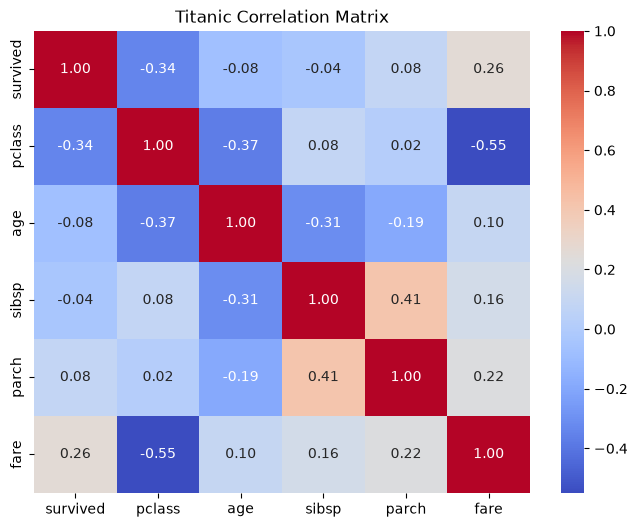


Two Strongest Correlations:
pclass  fare    -0.549500
sibsp   parch    0.414838
dtype: float64


In [4]:

# MODULE 2 PART A TASK 4 : CORRELATION MATRIX AND HEATMAPS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("titanic")

# 1. Survival rate by sex
male_survival = df[df["sex"] == "male"]["survived"].mean()
female_survival = df[df["sex"] == "female"]["survived"].mean()

print("Survival Rate by Sex")
print("Male:", male_survival)
print("Female:", female_survival)


# 2. Survival rate by pclass
class1 = df[df["pclass"] == 1]["survived"].mean()
class2 = df[df["pclass"] == 2]["survived"].mean()
class3 = df[df["pclass"] == 3]["survived"].mean()

print("\nSurvival Rate by Pclass")
print("Class 1:", class1)
print("Class 2:", class2)
print("Class 3:", class3)


# 3. Survival rate by sex AND pclass
female_class1 = df[(df["sex"] == "female") & (df["pclass"] == 1)]["survived"].mean()
female_class2 = df[(df["sex"] == "female") & (df["pclass"] == 2)]["survived"].mean()
female_class3 = df[(df["sex"] == "female") & (df["pclass"] == 3)]["survived"].mean()

male_class1 = df[(df["sex"] == "male") & (df["pclass"] == 1)]["survived"].mean()
male_class2 = df[(df["sex"] == "male") & (df["pclass"] == 2)]["survived"].mean()
male_class3 = df[(df["sex"] == "male") & (df["pclass"] == 3)]["survived"].mean()

print("\nSurvival Rate by Sex and Pclass")

print("Female, Class 1:", female_class1)

print("Female, Class 2:", female_class2)

print("Female, Class 3:", female_class3)

print("Male, Class 1:", male_class1)

print("Male, Class 2:", male_class2)

print("Male, Class 3:", male_class3)


# 4. Example of OR (|)
# Passengers who were female OR in first class
female_or_class1 = df[(df["sex"] == "female") | (df["pclass"] == 1)]

print("\nFemale OR Class 1 passengers:", len(female_or_class1))


# 5. Correlation matrix using EXACTLY six columns
columns = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

corr = df[columns].corr()

print("\nCorrelation Matrix")
print(corr)


# 6. Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Titanic Correlation Matrix")
plt.show()


# 7. Find the two strongest correlations
corr_pairs = corr.where(
    ~np.tril(np.ones(corr.shape)).astype(bool)
)

corr_pairs = corr_pairs.stack()
corr_pairs = corr_pairs.reindex(
    corr_pairs.abs().sort_values(ascending=False).index
)

print("\nTwo Strongest Correlations:")
print(corr_pairs.head(2))

Calling pd.read_csv() to load the data...
Calling sns.set_theme() to set a clean background for our charts...
- Generating Chart 1 -
Calling plt.figure() to set the chart size...
Calling sns.barplot() to plot Survival by Class and Sex...
Calling plt.title() to add a title...
Calling plt.show() to display the chart...


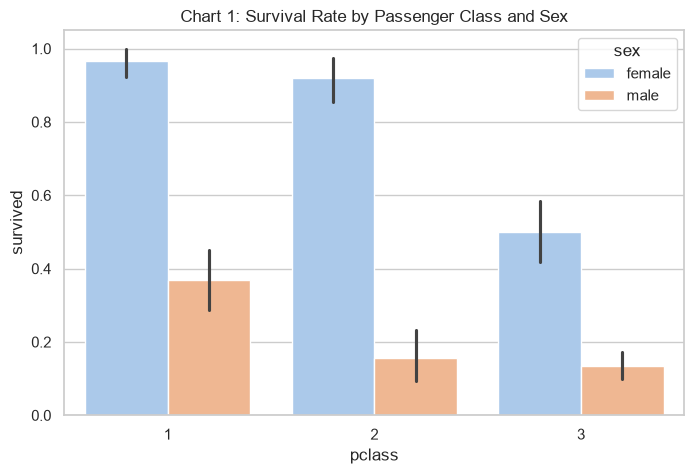

- Generating Chart 2 -
Calling plt.figure() to set the chart size...
Calling sns.boxplot() to plot Age vs. Survival separated by Sex...
Calling plt.title() to add a title...
Calling plt.show() to display the chart...


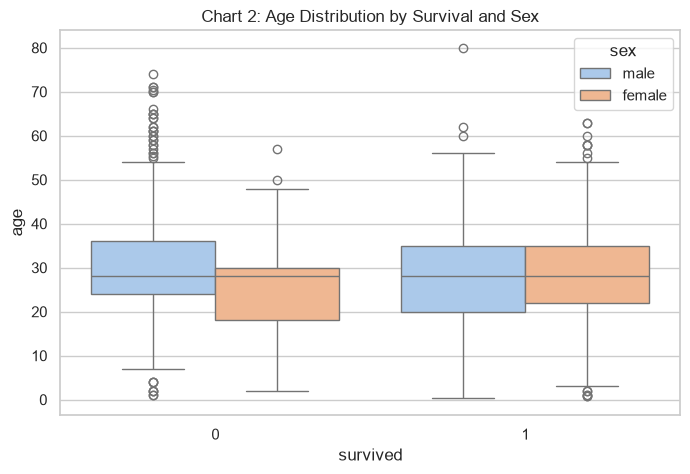

- Generating Chart 3 -
Calling plt.figure() to set the chart size...
Calling sns.scatterplot() to plot Ticket Fare vs Age...
Calling plt.title() to add a title...
Calling plt.show() to display the chart...


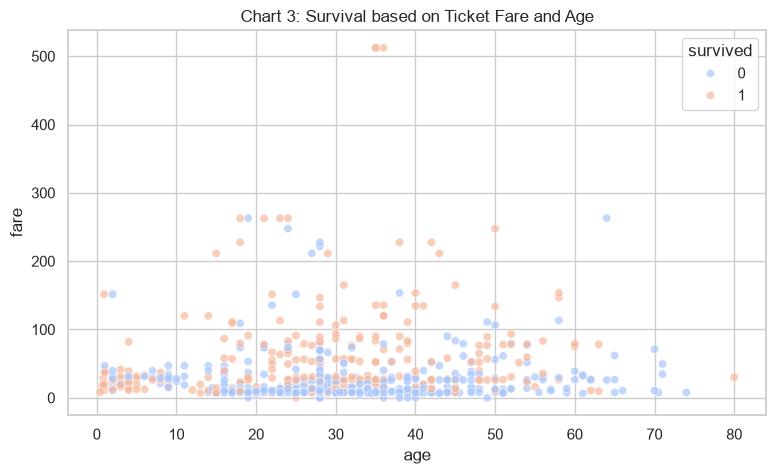

- Generating Chart 4 -
Calling df.select_dtypes() to grab only the number columns for math...
Calling numeric_df.corr() to calculate the math relationships...
Calling plt.figure() to set the chart size...
Calling sns.heatmap() to plot the correlation colors...
Calling plt.title() to add a title...
Calling plt.show() to display the chart...


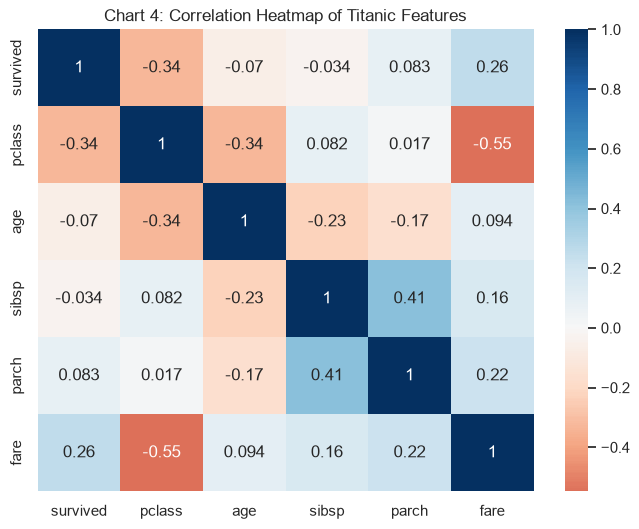

In [5]:

# MODULE 2 PART A TASK 5 : Multivariate "data story": produce at least 4 distinct charts

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Calling pd.read_csv() to load the data...")
df = pd.read_csv('titanic_clean.csv')

print("Calling sns.set_theme() to set a clean background for our charts...")
sns.set_theme(style="whitegrid")



# CHART 1: BAR PLOT (Sex and Class)

print("- Generating Chart 1 -")

print("Calling plt.figure() to set the chart size...")

plt.figure(figsize=(8, 5))

print("Calling sns.barplot() to plot Survival by Class and Sex...")

sns.barplot(data=df, x='pclass', y='survived', hue='sex', palette='pastel')

print("Calling plt.title() to add a title...")

plt.title("Chart 1: Survival Rate by Passenger Class and Sex")

print("Calling plt.show() to display the chart...")

plt.show()



# CHART 2: BOX PLOT (Age, Sex, and Survival)


print("- Generating Chart 2 -")

print("Calling plt.figure() to set the chart size...")

plt.figure(figsize=(8, 5))

print("Calling sns.boxplot() to plot Age vs. Survival separated by Sex...")

sns.boxplot(data=df, x='survived', y='age', hue='sex', palette='pastel')

print("Calling plt.title() to add a title...")

plt.title("Chart 2: Age Distribution by Survival and Sex")

print("Calling plt.show() to display the chart...")

plt.show()


# CHART 3: SCATTER PLOT (Fare, Age, and Survival)

print("- Generating Chart 3 -")

print("Calling plt.figure() to set the chart size...")

plt.figure(figsize=(9, 5))

print("Calling sns.scatterplot() to plot Ticket Fare vs Age...")

sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.7, palette='coolwarm')

print("Calling plt.title() to add a title...")

plt.title("Chart 3: Survival based on Ticket Fare and Age")

print("Calling plt.show() to display the chart...")

plt.show()


# CHART 4: HEATMAP (Correlation of all numbers)

print("- Generating Chart 4 -")

print("Calling df.select_dtypes() to grab only the number columns for math...")

numeric_df = df.select_dtypes(include=['number'])

print("Calling numeric_df.corr() to calculate the math relationships...")

correlation_matrix = numeric_df.corr()

print("Calling plt.figure() to set the chart size...")

plt.figure(figsize=(8, 6))

print("Calling sns.heatmap() to plot the correlation colors...")

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)

print("Calling plt.title() to add a title...")

plt.title("Chart 4: Correlation Heatmap of Titanic Features")

print("Calling plt.show() to display the chart...")

plt.show()


Before vs After:
   age_mean_before  age_std_before  age_mean_after  age_std_after  \
0          29.3152         12.9849             0.0         1.0006   

   fare_mean_before  fare_std_before  fare_mean_after  fare_std_after  
0           32.0967          49.6975              0.0          1.0006  


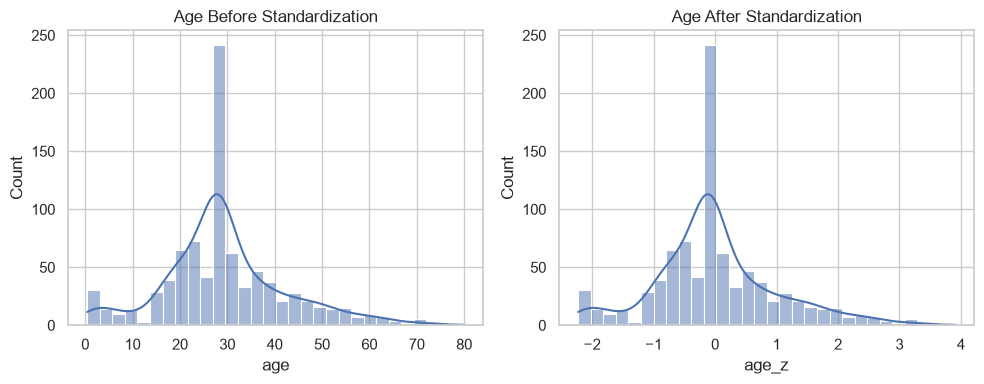

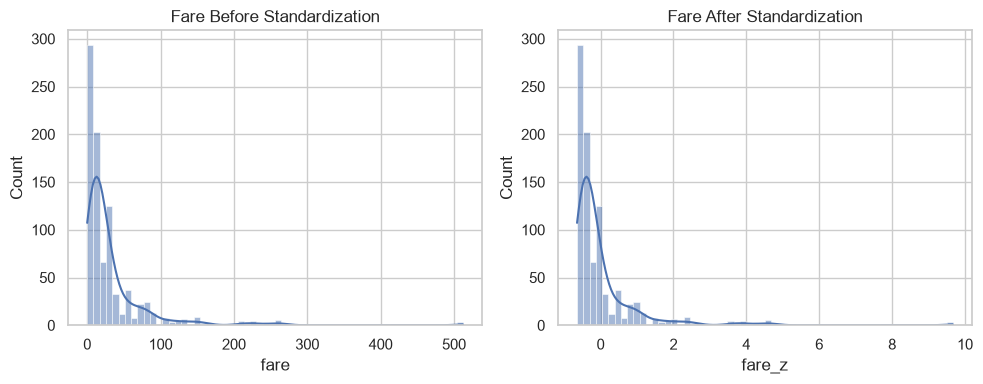

In [6]:

#MODULE 2 PART A TASK 6 : EDA BEORE MODELING AND AFTER MODELING

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
columns = ["age", "fare"]

scaler = StandardScaler()
df_eda = df.copy()
df_eda[["age_z", "fare_z"]] = scaler.fit_transform( df_eda[["age", "fare"]] )

comparison = pd.DataFrame({ "age_mean_before": [df["age"].mean()],
                           "age_std_before": [df["age"].std()],
                            "age_mean_after": [df_eda["age_z"].mean()],
                            "age_std_after": [df_eda["age_z"].std()],
                            "fare_mean_before": [df["fare"].mean()],
                            "fare_std_before": [df["fare"].std()],
                            "fare_mean_after": [df_eda["fare_z"].mean()],
                            "fare_std_after": [df_eda["fare_z"].std()] })
print("\nBefore vs After:")
print(comparison.round(4))
# Age before and after
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["age"], kde=True)
plt.title("Age Before Standardization")

plt.subplot(1, 2, 2)
sns.histplot(df_eda["age_z"], kde=True)
plt.title("Age After Standardization")

plt.tight_layout()
plt.show()


# Fare before and after
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["fare"], kde=True)
plt.title("Fare Before Standardization")

plt.subplot(1, 2, 2)
sns.histplot(df_eda["fare_z"], kde=True)
plt.title("Fare After Standardization")

plt.tight_layout()
plt.show()


# THIS CODE WAS WRITTEN ON 17/9/2026

MODULE 2 - PART A - 1-6 TASKS COMPLETED HERE